# ETL Pipeline & Reconciliation


Raw PaySim CSV → validation → SQLite → settlement reconciliation

---

### What this notebook does

**ETL**
Ingests the raw PaySim transaction data, creates a stable transaction ID, runs data quality checks, and quarantines rejected rows with tagged rejection reasons. Only clean data is loaded into a local SQLite database with an index for downstream joins.

**Reconciliation**
Simulates a counterparty settlement file with realistic corruptions: amount tampering, missing transactions, and duplicate entries. Then reconciles it against the system-of-record table. Discrepancies are classified into four buckets: missing settlements, phantom transactions, duplicate settlements, and amount mismatches.

**Analytical views**
Defines SQL views for daily transaction volume, per-user spend summary, and balance anomaly detection.

---

> `isfraud` is excluded at ingestion. Ground-truth labels are unavailable at transaction time in production.
> `isflaggedfraud` is retained as output from an assumed rule-based detection system.  
> Clean output feeds into `02_fraud_detection.ipynb`.

For detail about Paysim dataset, visit https://www.kaggle.com/datasets/ealaxi/paysim1.
Also, check out `DataDescription.md`.

# 1. ETL pipeline

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import sqlite3
import hashlib

## INGESTION

In [2]:
df = pd.read_csv("data/raw/paysim.csv")
df.columns = df.columns.str.lower()

# first look 
print(df.shape)
print(df.dtypes)
df.head()

(6362620, 11)
step                int64
type                  str
amount            float64
nameorig              str
oldbalanceorg     float64
newbalanceorig    float64
namedest              str
oldbalancedest    float64
newbalancedest    float64
isfraud             int64
isflaggedfraud      int64
dtype: object


,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## LABEL HANDLING

isfraud is ground-truth available only in simulation, not in production.

isflaggedfraud is retained, it represents output from an assumed rule-based detection system.

See DataDescription.md for details.

In [3]:

df = df.drop(columns=['isfraud'])

## TRANSACTION ID
Created so that every row, including rejected ones, carries a stable ID number.

SHA-256 over all business-meaningful columns, truncated to 16 hex chars (64 bits).

Collision probability across ~6M rows is ~2e-9, which is effectively zero.

String concatenation is vectorised, the .map() for hashing is the unavoidable serial step (~30–60s on full dataset).


In [4]:
key_cols = [
    'step', 'type', 'amount',
    'nameorig', 'oldbalanceorg', 'newbalanceorig',
    'namedest', 'oldbalancedest', 'newbalancedest'
]

hash_input = (
    df['step'].astype(str)          + '|' +
    df['type']                      + '|' +
    df['amount'].astype(str)        + '|' +
    df['nameorig']                  + '|' +
    df['oldbalanceorg'].astype(str) + '|' +
    df['newbalanceorig'].astype(str)+ '|' +
    df['namedest']                  + '|' +
    df['oldbalancedest'].astype(str)+ '|' +
    df['newbalancedest'].astype(str)
)

df['txn_id'] = hash_input.map(lambda s: hashlib.sha256(s.encode()).hexdigest()[:16])

print(f"[INFO] txn_id unique: {df['txn_id'].nunique()} / {len(df)} rows")


[INFO] txn_id unique: 6362620 / 6362620 rows


## DATA QUALITY CHECKS & VALIDATION

A simple data quality check to identify potential issues before loading into the database.

In [5]:
non_issues = []
issues = []

# nulls
null_counts = df.isnull().sum()
if null_counts.any():
    issues.append(f"Nulls found: {null_counts[null_counts > 0].to_dict()}")
else:
    non_issues.append("No null values")

# negative amounts
neg = df[df['amount'] <= 0]
if len(neg):
    issues.append(f"{len(neg)} rows with non-positive amount")
else:
    non_issues.append("No non-positive amounts")

# unknown transaction types
valid_types = {'TRANSFER', 'PAYMENT', 'CASH_OUT', 'CASH_IN', 'DEBIT'}
bad_types = df[~df['type'].isin(valid_types)]
if len(bad_types):
    issues.append(f"{len(bad_types)} rows with unknown type")
else:
    non_issues.append("No unknown transaction types")

# duplicates
dupes = df.duplicated().sum()
if dupes:
    issues.append(f"{dupes} duplicate rows")
else:
    non_issues.append("No duplicate rows")

# report
for i in issues:     print(f"[WARN] {i}")
for i in non_issues: print(f"[OK]   {i}")


[WARN] 16 rows with non-positive amount
[OK]   No null values
[OK]   No unknown transaction types
[OK]   No duplicate rows


In [6]:
# show all non-positive amounts
print(neg[['type', 'amount']])

             type  amount
2736447  CASH_OUT     0.0
3247298  CASH_OUT     0.0
3760289  CASH_OUT     0.0
5563714  CASH_OUT     0.0
5996408  CASH_OUT     0.0
5996410  CASH_OUT     0.0
6168500  CASH_OUT     0.0
6205440  CASH_OUT     0.0
6266414  CASH_OUT     0.0
6281483  CASH_OUT     0.0
6281485  CASH_OUT     0.0
6296015  CASH_OUT     0.0
6351226  CASH_OUT     0.0
6362461  CASH_OUT     0.0
6362463  CASH_OUT     0.0
6362585  CASH_OUT     0.0


OK. since all are 0

## QUARANTINE

This is a simple example of row-level quarantine. we identify bad rows, tag them with a reason, and save them for later review. 

Keeping rejected rows separate, rather than silently dropping them, is helpful for auditing and improving data quality over time, as you can analyze the rejected rows later.

In production, you might want to log these to a monitoring system or database instead.

In [7]:

critical_cols = ['amount', 'nameorig', 'namedest', 'type', 'step']
valid_types = {'TRANSFER', 'PAYMENT', 'CASH_OUT', 'CASH_IN', 'DEBIT'}

rejected_frames = []

# 1. Nulls in critical fields
nulls_mask = df[critical_cols].isnull().any(axis=1)
if nulls_mask.sum():
    bad = df[nulls_mask].copy()
    bad['rejection_reason'] = 'null_in_critical_field'
    rejected_frames.append(bad)

# 2. Duplicates
dupes_mask = df.duplicated()
if dupes_mask.sum():
    bad = df[dupes_mask].copy()
    bad['rejection_reason'] = 'duplicate_row'
    rejected_frames.append(bad)

# 3. Negative or zero amounts
neg_mask = df['amount'] <= 0
if neg_mask.sum():
    bad = df[neg_mask].copy()
    bad['rejection_reason'] = 'non_positive_amount'
    rejected_frames.append(bad)

# 4. Unknown transaction types
type_mask = ~df['type'].isin(valid_types)
if type_mask.sum():
    bad = df[type_mask].copy()
    bad['rejection_reason'] = 'unknown_transaction_type'
    rejected_frames.append(bad)

# 5. Flagged fraud: blocked before settlement
flagged_mask = df['isflaggedfraud'] == 1
if flagged_mask.sum():
    bad = df[flagged_mask].copy()
    bad['rejection_reason'] = 'blocked_flagged_fraud'
    rejected_frames.append(bad)

# combine and save quarantine
if rejected_frames:
    rejected = pd.concat(rejected_frames).drop_duplicates().reset_index(drop=True)
    rejected['rejected_at'] = pd.Timestamp.now()
    rejected.to_csv("data/quarantine/rejected_rows.csv", index=False)
    print(f"[WARN] Quarantined {len(rejected)} rows → data/quarantine/rejected_rows.csv")
else:
    print("[OK] No rows quarantined")

# build clean mask and filter
all_bad = nulls_mask | dupes_mask | neg_mask | type_mask | flagged_mask
df_clean = df[~all_bad].copy()
print(f"[INFO] Clean dataset: {len(df_clean)} rows")

[WARN] Quarantined 32 rows → data/quarantine/rejected_rows.csv


[INFO] Clean dataset: 6362588 rows


## LOAD TO SQL Database
Only clean rows are written to the system-of-record table.
The index on txn_id is required for performant outer joins during reconciliation.


In [8]:
conn = sqlite3.connect("db/transactions.db")

# Only the clean rows become the system of record. Quarantined rows live in
# data/quarantine/ and must never enter the transactions table.
df_clean.to_sql("transactions", conn, if_exists="replace", index=False)

conn.execute("CREATE INDEX IF NOT EXISTS idx_txn_id ON transactions(txn_id)")
conn.commit()

# verify
count = pd.read_sql("SELECT COUNT(*) as n FROM transactions", conn)
print(f"Loaded: {count['n'][0]} rows")

Loaded: 6362588 rows


# 2. SETTLEMENT SIMULATION

Simulates a counterparty settlement file with three realistic corruption types:
amount tampering (FX rounding etc), missing transactions (failed settlement),
and duplicate entries (double settlement).

Create a corrupted "settlement file", then diff it against the DB.

In [9]:
settlement = df_clean.copy()
corruption_log = []

# 1. Amount tampering (FX rounding / processing errors)
idx = settlement.sample(frac=0.005, random_state=42).index
settlement.loc[idx, 'amount'] = (settlement.loc[idx, 'amount'] * 1.001).round(2)
corruption_log.append({"type": "amount_mismatch", "count": len(idx)})

# 2. Missing transactions (failed settlement)
drop_idx = settlement.sample(frac=0.003, random_state=1).index
settlement = settlement.drop(drop_idx)
corruption_log.append({"type": "missing_in_settlement", "count": len(drop_idx)})

# 3. Duplicate transactions (double settlement)
dupes = settlement.sample(frac=0.002, random_state=2)
settlement = pd.concat([settlement, dupes]).reset_index(drop=True)
corruption_log.append({"type": "duplicates_injected", "count": len(dupes)})

print("Corruption log:")
for c in corruption_log:
    print(f"  {c['type']}: {c['count']} rows")

settlement.to_csv("data/corrupted/settlement.csv", index=False)

Corruption log:
  amount_mismatch: 31813 rows
  missing_in_settlement: 19088 rows
  duplicates_injected: 12687 rows


## RECONCILIATION

A simple reconciliation process. We compare the system-of-record table against the settlement file and classify every discrepancy. In production this would run on a schedule with alert thresholds on each discrepancy bucket.

We detect four discrepancy types:

- **Missing in settlement** — a system transaction that was never settled.
- **Phantom in settlement** — a settled transaction with no system record.
- **Duplicate settlements** — a system transaction settled more than once (double settlement).
- **Amount mismatches** — the settled amount differs from the system amount.

> A plain outer join with `indicator=True` **cannot** detect duplicates: when a `txn_id` appears on both sides, every copy is matched and tagged `both`, so injected double-settlements silently disappear into the matched bucket. We therefore compare per-`txn_id` occurrence counts directly.

In [10]:
system     = pd.read_sql("SELECT * FROM transactions", conn)
settlement = pd.read_csv("data/corrupted/settlement.csv")

# System is one row per txn_id; settlement may legitimately repeat a txn_id
# (double settlement). An outer-join indicator can't see that, so we reconcile
# on per-txn_id occurrence counts instead.
sys_ids    = set(system['txn_id'])
stl_counts = settlement['txn_id'].value_counts()
stl_ids    = set(stl_counts.index)

# 1. Missing in settlement: in system, never settled
missing = sys_ids - stl_ids

# 2. Phantom in settlement: settled but no system record
phantom = stl_ids - sys_ids

# 3. Duplicate settlements: a system txn settled more than once
duplicate_ids   = [tid for tid, c in stl_counts.items() if c > 1 and tid in sys_ids]
duplicate_extra = int(sum(c - 1 for tid, c in stl_counts.items() if c > 1 and tid in sys_ids))

# 4. Amount mismatches: one settlement row per txn_id vs system
stl_unique = settlement.drop_duplicates('txn_id', keep='first')
matched = system[['txn_id', 'amount', 'type']].merge(
    stl_unique[['txn_id', 'amount']],
    on='txn_id', suffixes=('_sys', '_stl'), how='inner'
)
matched['amount_diff'] = (matched['amount_sys'] - matched['amount_stl']).abs()
mismatches = matched[matched['amount_diff'] > 0.01]

print(f"Missing in settlement : {len(missing)}")
print(f"Phantom in settlement : {len(phantom)}")
print(f"Duplicate settlements : {len(duplicate_ids)} ids ({duplicate_extra} extra rows)")
print(f"Amount mismatches     : {len(mismatches)}")

Missing in settlement : 19088
Phantom in settlement : 0
Duplicate settlements : 12687 ids (12687 extra rows)
Amount mismatches     : 31706


In [11]:
total = len(system)
recon_summary = {
    "total_system_txns"     : total,
    "matched_clean"         : len(matched) - len(mismatches),
    "amount_mismatches"     : len(mismatches),
    "missing_in_settlement" : len(missing),
    "phantom_in_settlement" : len(phantom),
    "duplicate_settlements" : len(duplicate_ids),
    "match_rate_pct"        : round((len(matched) - len(mismatches)) / total * 100, 2),
}

for k, v in recon_summary.items():
    print(f"{k:30s}: {v}")

total_system_txns             : 6362588
matched_clean                 : 6311794
amount_mismatches             : 31706
missing_in_settlement         : 19088
phantom_in_settlement         : 0
duplicate_settlements         : 12687
match_rate_pct                : 99.2


# 3. ANALYTICAL VIEWS
Materialised as SQL views so downstream consumers query pre-defined business logic
rather than raw tables. Column names follow the lowercased schema applied at ingestion.

Write SQL views that define business metrics clearly

In [12]:
# csv columns:
# step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud

queries = {
    "daily_volume": """
        CREATE VIEW daily_volume AS
        SELECT step, type, COUNT(*) AS txn_count, SUM(amount) AS total_volume
        FROM transactions
        GROUP BY step, type
    """,
    "user_summary": """
        CREATE VIEW user_summary AS
        SELECT nameorig,
               COUNT(*)    AS txn_count,
               SUM(amount) AS total_spent,
               AVG(amount) AS avg_txn
        FROM transactions
        GROUP BY nameorig
    """,
    # Tightened: only flag senders that actually held funds (oldbalanceorg > 0).
    # Without this guard, every CASH_OUT/TRANSFER with a 0 opening balance — the
    # bulk of the table — trips the rule and drowns out genuine anomalies.
    "balance_anomalies": """
        CREATE VIEW balance_anomalies AS
        SELECT *,
               ROUND(newbalanceorig - (oldbalanceorg - amount), 2) AS balance_error
        FROM transactions
        WHERE type IN ('TRANSFER', 'CASH_OUT')
          AND oldbalanceorg > 0
          AND ABS(oldbalanceorg - amount - newbalanceorig) > 0.01
    """
}

# DROP first so re-runs pick up the latest definition. CREATE VIEW IF NOT EXISTS
# would silently keep a stale view from a previous run on the same .db file.
for name, q in queries.items():
    conn.execute(f"DROP VIEW IF EXISTS {name}")
    conn.execute(q)
    print(f"[INFO] Created view: {name}")

conn.commit()

[INFO] Created view: daily_volume
[INFO] Created view: user_summary
[INFO] Created view: balance_anomalies


## Analytical Views 

**`daily_volume`**
Transaction count and total volume grouped by time step and transaction type. Useful for spotting unusual spikes in activity, a sudden surge in `CASH_OUT` at a given step is a signal worth investigating.

**`user_summary`**
Per-originator aggregates: transaction count, total spend, and average transaction size. Feeds feature engineering in the fraud detection notebook. High-frequency or high-value accounts are interesting.

**`balance_anomalies`**
Flags rows where the originator's closing balance doesn't match the expected value after deducting the transaction amount (`oldbalanceOrg - amount ≈ newbalanceOrig`), exposing the residual as `balance_error`. Restricted to `TRANSFER`/`CASH_OUT` senders that actually held a balance (`oldbalanceorg > 0`) — zero-opening-balance rows are a PaySim artifact and would otherwise dominate the view.

In [13]:
pd.read_sql("SELECT * FROM daily_volume order by txn_count desc", conn)

,step,type,txn_count,total_volume
0,19,CASH_OUT,19822,3.072410e+09
1,18,CASH_OUT,19440,3.194589e+09
2,187,CASH_OUT,18646,2.858251e+09
3,235,CASH_OUT,18494,2.805594e+09
4,139,CASH_OUT,17980,2.837199e+09
...,...,...,...,...
2724,662,TRANSFER,1,1.468304e+06
2725,679,DEBIT,1,8.760240e+03
2726,698,DEBIT,1,3.233000e+02
2727,707,DEBIT,1,2.638030e+03


In [14]:
pd.read_sql("SELECT * FROM user_summary order by total_spent desc", conn) 

,nameorig,txn_count,total_spent,avg_txn
0,C1715283297,1,92445516.64,92445516.64
1,C2127282686,1,73823490.36,73823490.36
2,C2044643633,1,71172480.42,71172480.42
3,C1425667947,1,69886731.30,69886731.30
4,C1584456031,1,69337316.27,69337316.27
...,...,...,...,...
6353270,C807337950,1,0.03,0.03
6353271,C1371059152,1,0.02,0.02
6353272,C344473063,1,0.02,0.02
6353273,C421116740,1,0.02,0.02


In [15]:
pd.read_sql("SELECT * FROM balance_anomalies order by amount desc", conn)

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isflaggedfraud,txn_id,balance_error
0,303,TRANSFER,57787800.93,C208486812,42228.75,0.00,C1087955840,1.368736e+08,1.946614e+08,0,e1e4d205a76b7e14,57745572.18
1,303,TRANSFER,51141938.17,C1483754162,310058.79,0.00,C531111973,8.708182e+07,1.382238e+08,0,2044031eb3c6385b,50831879.38
2,303,TRANSFER,47504216.38,C539714486,17047.14,0.00,C190688669,7.780234e+07,1.253066e+08,0,b57b0105990de7d8,47487169.24
3,303,TRANSFER,45372634.63,C240100497,5819.77,0.00,C1789550256,9.404946e+07,1.394221e+08,0,39104a0a6c66fb1d,45366814.86
4,303,TRANSFER,42183808.56,C1835360608,266493.90,0.00,C8271807,6.780774e+07,1.099915e+08,0,d5ab93bc993b5f27,41917314.66
...,...,...,...,...,...,...,...,...,...,...,...,...
1191465,332,CASH_OUT,70.97,C733941443,27204.41,27133.45,C1187838968,3.000382e+06,3.000453e+06,0,d0d46b37a59eb338,0.01
1191466,566,CASH_OUT,55.14,C42469272,12745.84,12690.69,C1266072540,1.585950e+06,1.586005e+06,0,ca429a30218ef4d5,-0.01
1191467,306,CASH_OUT,35.81,C1587804994,165525.14,165489.32,C128611275,2.035757e+06,2.035793e+06,0,b48b3f3163a9851a,-0.01
1191468,229,TRANSFER,25.96,C1615536803,57389.99,57364.04,C838219899,7.498979e+05,7.499239e+05,0,d014aabfc6d3c696,0.01


## A quick look at the views

Instead of only printing rows, here is a light visual summary built from the `daily_volume` view: how much money moves through each transaction type, and how transaction volume changes over the roughly 30 day window.

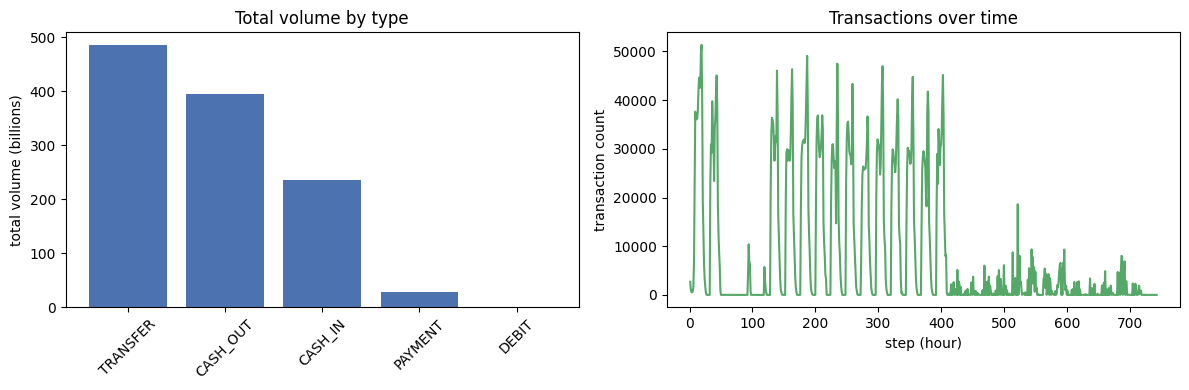

In [16]:
import matplotlib.pyplot as plt

# pull the daily_volume view and summarise it two simple ways
dv = pd.read_sql("SELECT step, type, txn_count, total_volume FROM daily_volume", conn)
by_type = dv.groupby('type')[['txn_count', 'total_volume']].sum().sort_values('total_volume', ascending=False)
by_step = dv.groupby('step')['txn_count'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# total money moved per transaction type (in billions)
axes[0].bar(by_type.index, by_type['total_volume'] / 1e9, color='#4C72B0')
axes[0].set_title('Total volume by type')
axes[0].set_ylabel('total volume (billions)')
axes[0].tick_params(axis='x', rotation=45)

# number of transactions per hour across the ~30 day window
axes[1].plot(by_step.index, by_step.values, color='#55A868')
axes[1].set_title('Transactions over time')
axes[1].set_xlabel('step (hour)')
axes[1].set_ylabel('transaction count')

plt.tight_layout()
plt.show()

In [17]:
conn.close()